In [4]:
#MULTIVARIATE ANALYSIS

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [6]:
cleaned_df = pd.read_csv("cleaned_itsm_data.csv")

print("Cleaned dataset loaded successfully!")
print("Shape:", cleaned_df.shape)

Cleaned dataset loaded successfully!
Shape: (360000, 29)


In [7]:
numerical_columns = cleaned_df.select_dtypes(include="number").columns

print("Numerical Columns:")
print(numerical_columns.tolist())

Numerical Columns:
['ticket_id', 'company_id', 'requester_user_id', 'assigned_agent_id', 'reopen_count', 'customer_satisfaction_rating', 'sla_log_id', 'sla_target_minutes', 'actual_minutes', 'breach_minutes', 'sla_variance_minutes', 'sla_performance_percentage']


In [8]:
correlation_data = cleaned_df[
    [
        "reopen_count",
        "customer_satisfaction_rating",
        "sla_target_minutes",
        "actual_minutes",
        "breach_minutes",
        "sla_variance_minutes",
        "sla_performance_percentage"
    ]
].corr()

print(correlation_data)

                              reopen_count  customer_satisfaction_rating  \
reopen_count                           NaN                           NaN   
customer_satisfaction_rating           NaN                  1.000000e+00   
sla_target_minutes                     NaN                 -1.993855e-19   
actual_minutes                         NaN                 -6.175744e-05   
breach_minutes                         NaN                 -7.027678e-05   
sla_variance_minutes                   NaN                 -8.043457e-05   
sla_performance_percentage             NaN                 -1.077527e-03   

                              sla_target_minutes  actual_minutes  \
reopen_count                                 NaN             NaN   
customer_satisfaction_rating       -1.993855e-19       -0.000062   
sla_target_minutes                  1.000000e+00        0.999544   
actual_minutes                      9.995442e-01        1.000000   
breach_minutes                      9.994588e-01   

In [9]:
sla_multivariate = cleaned_df[
    [
        "sla_type",
        "sla_status",
        "actual_minutes",
        "sla_performance_percentage"
    ]
]

print(
    sla_multivariate.groupby(
        ["sla_type", "sla_status"]
    )[[
        "actual_minutes",
        "sla_performance_percentage"
    ]].mean()
)

                           actual_minutes  sla_performance_percentage
sla_type       sla_status                                            
First Response Breached        272.455164                  227.045970
               Met              62.496640                   52.080533
Resolution     Breached       5893.000000                  409.236111


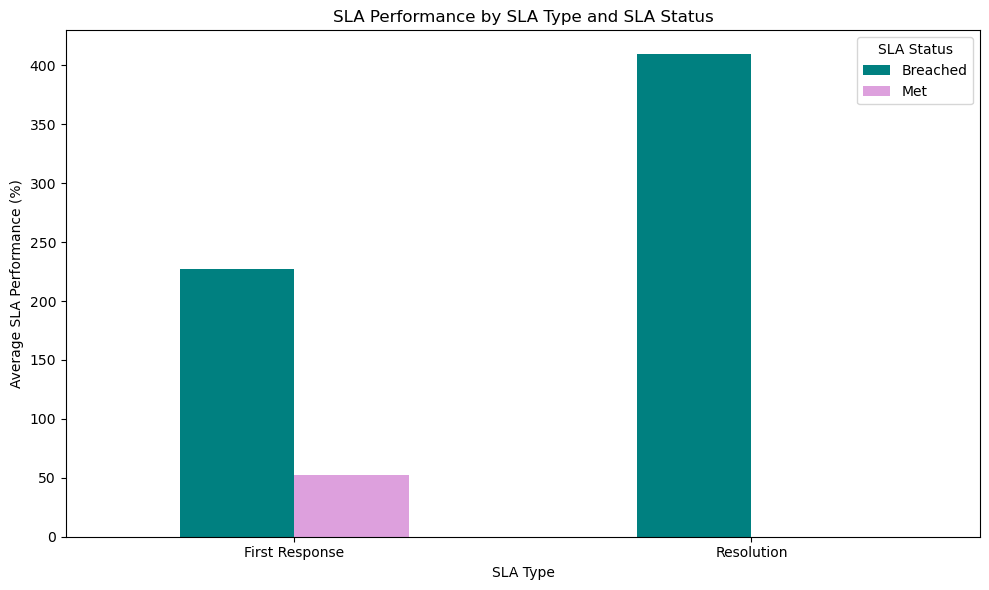

In [13]:
sla_multivariate.groupby(
    ["sla_type", "sla_status"]
)["sla_performance_percentage"].mean().unstack().plot(
    kind="bar",
    figsize=(10, 6),
    color=["teal", "plum"]
)

plt.title("SLA Performance by SLA Type and SLA Status")
plt.xlabel("SLA Type")
plt.ylabel("Average SLA Performance (%)")
plt.xticks(rotation=0)
plt.legend(title="SLA Status")
plt.tight_layout()

plt.savefig(
    "SLA_Performance_Multivariate.svg",
    format="svg"
)

plt.show()

In [14]:
resolution_multivariate = cleaned_df[
    [
        "resolution_code",
        "sla_status",
        "actual_minutes",
        "sla_variance_minutes"
    ]
]

print(
    resolution_multivariate.groupby(
        ["resolution_code", "sla_status"]
    )[[
        "actual_minutes",
        "sla_variance_minutes"
    ]].mean()
)

                                     actual_minutes  sla_variance_minutes
resolution_code          sla_status                                      
Access Granted           Breached       3536.484867           2649.916499
                         Met              62.962993            -57.037007
Configuration Updated    Breached       3536.069804           2649.665353
                         Met              62.106247            -57.893753
Known Error Workaround   Breached       3536.381419           2649.784181
                         Met              62.908613            -57.091387
Password Reset Completed Breached       3535.325552           2649.104440
                         Met              62.778784            -57.221216
Patch Applied            Breached       3530.470623           2645.284658
                         Met              62.637140            -57.362860
Resolved by KB Article   Breached       3540.466691           2653.019277
                         Met          

In [15]:
csat_multivariate = cleaned_df[
    [
        "customer_satisfaction_rating",
        "actual_minutes",
        "sla_performance_percentage",
        "sla_status"
    ]
].dropna()

print(
    csat_multivariate.groupby("sla_status")[
        [
            "customer_satisfaction_rating",
            "actual_minutes",
            "sla_performance_percentage"
        ]
    ].mean()
)

            customer_satisfaction_rating  actual_minutes  \
sla_status                                                 
Breached                        3.008003     3535.028153   
Met                             3.012371       62.495240   

            sla_performance_percentage  
sla_status                              
Breached                    332.817246  
Met                          52.079367  


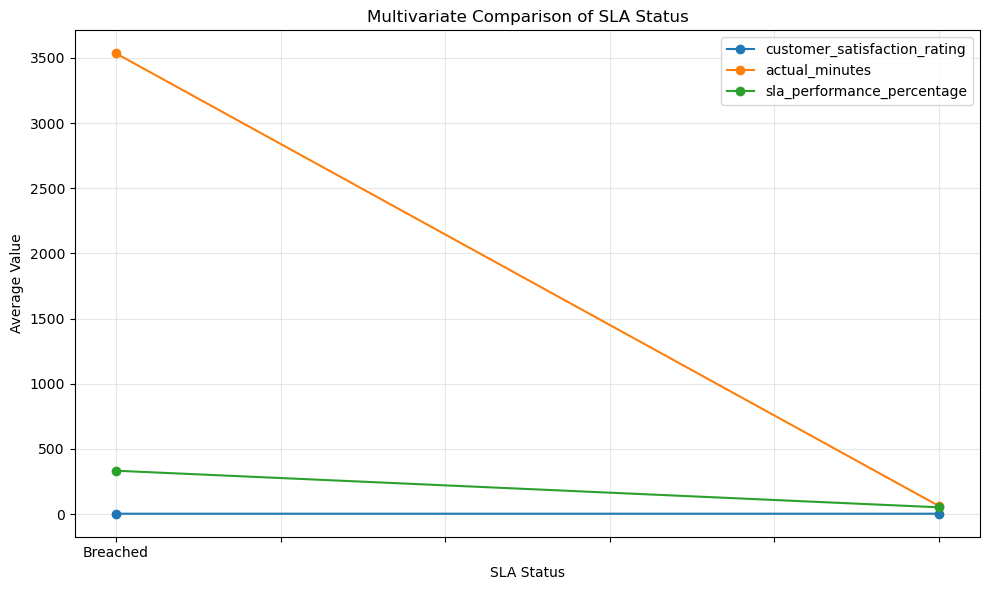

In [16]:
csat_multivariate.groupby("sla_status")[
    [
        "customer_satisfaction_rating",
        "actual_minutes",
        "sla_performance_percentage"
    ]
].mean().plot(
    kind="line",
    marker="o",
    figsize=(10, 6)
)

plt.title("Multivariate Comparison of SLA Status")
plt.xlabel("SLA Status")
plt.ylabel("Average Value")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(
    "CSAT_ActualTime_SLA_Performance_Multivariate.svg",
    format="svg"
)

plt.show()

In [17]:
sla_type_multivariate = cleaned_df[
    [
        "sla_type",
        "actual_minutes",
        "sla_variance_minutes",
        "sla_performance_percentage"
    ]
]

print(
    sla_type_multivariate.groupby("sla_type")[
        [
            "actual_minutes",
            "sla_variance_minutes",
            "sla_performance_percentage"
        ]
    ].mean()
)

                actual_minutes  sla_variance_minutes  \
sla_type                                               
First Response       214.14035              94.14035   
Resolution          5893.00000            4453.00000   

                sla_performance_percentage  
sla_type                                    
First Response                  178.450292  
Resolution                      409.236111  


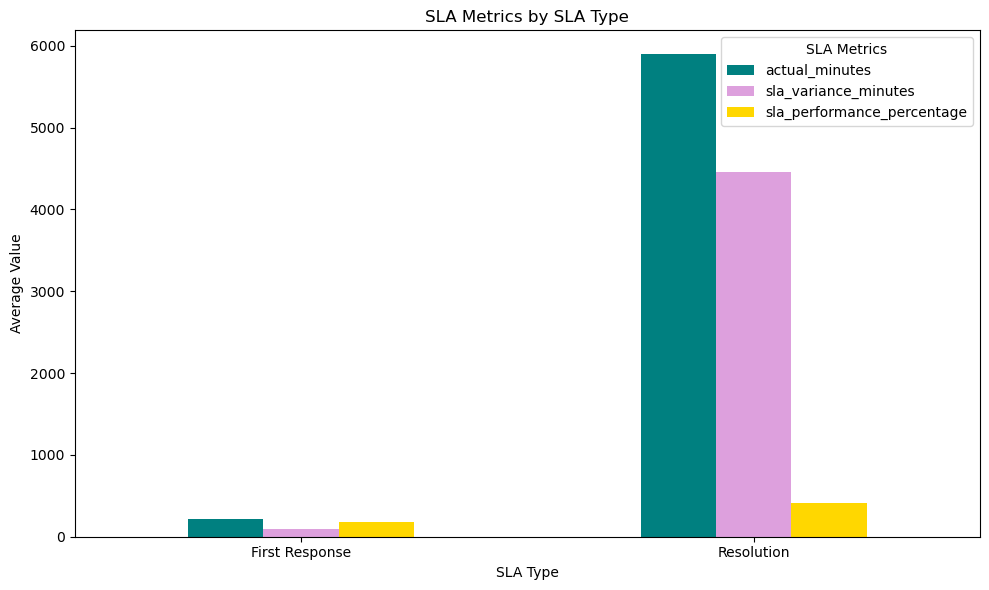

In [18]:
sla_type_multivariate.groupby("sla_type")[
    [
        "actual_minutes",
        "sla_variance_minutes",
        "sla_performance_percentage"
    ]
].mean().plot(
    kind="bar",
    figsize=(10, 6),
    color=["teal", "plum", "gold"]
)

plt.title("SLA Metrics by SLA Type")
plt.xlabel("SLA Type")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.legend(title="SLA Metrics")
plt.tight_layout()

plt.savefig(
    "SLA_Metrics_by_SLA_Type.svg",
    format="svg"
)

plt.show()